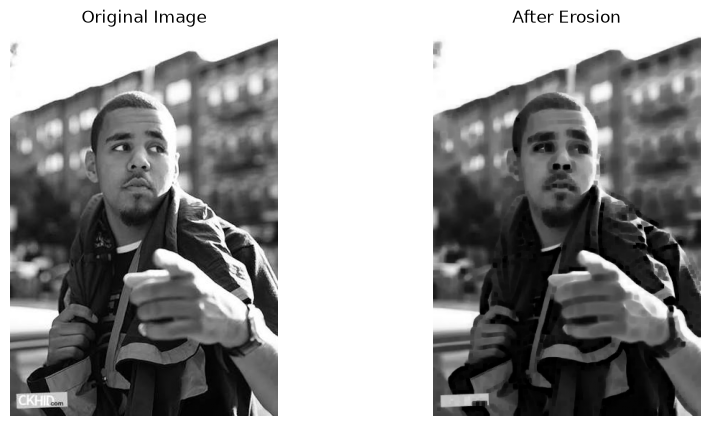

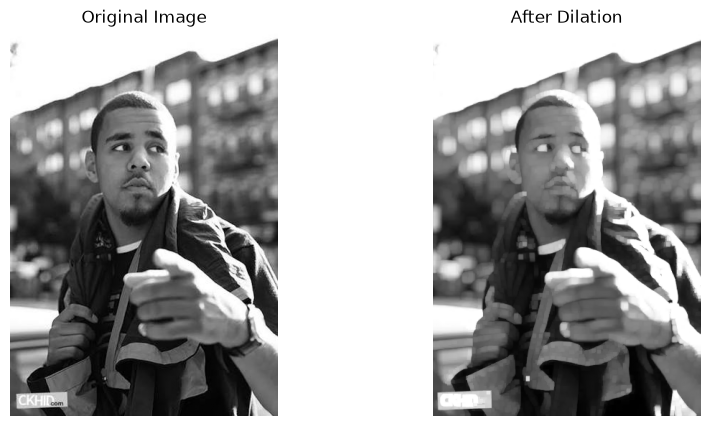

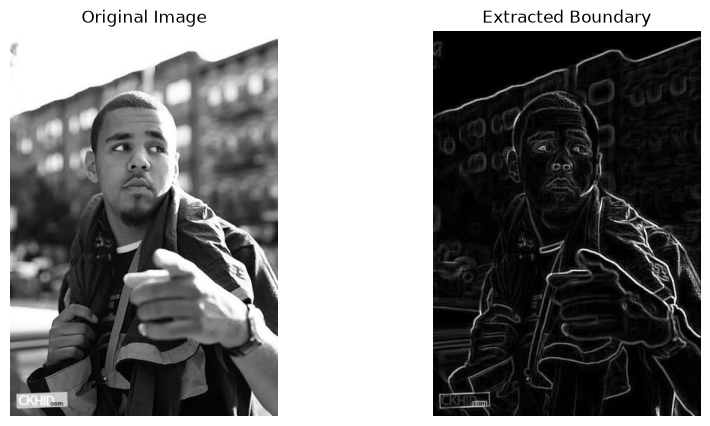

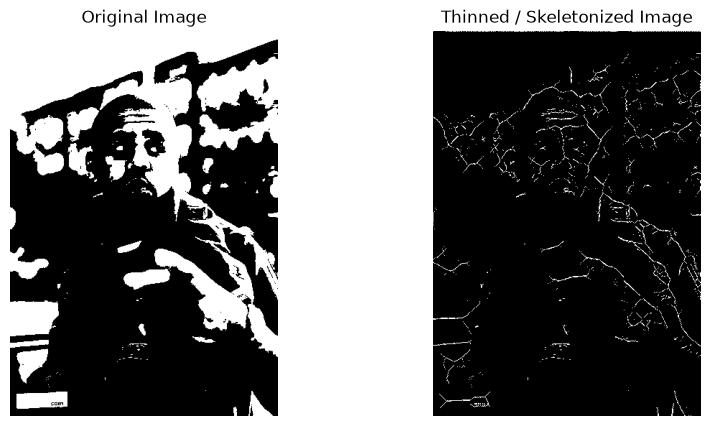

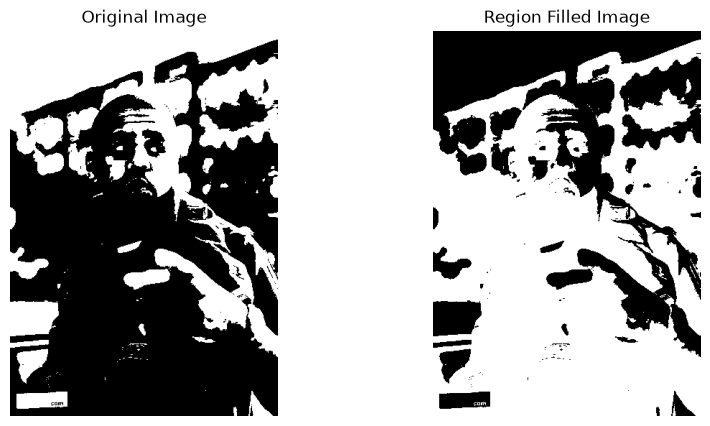

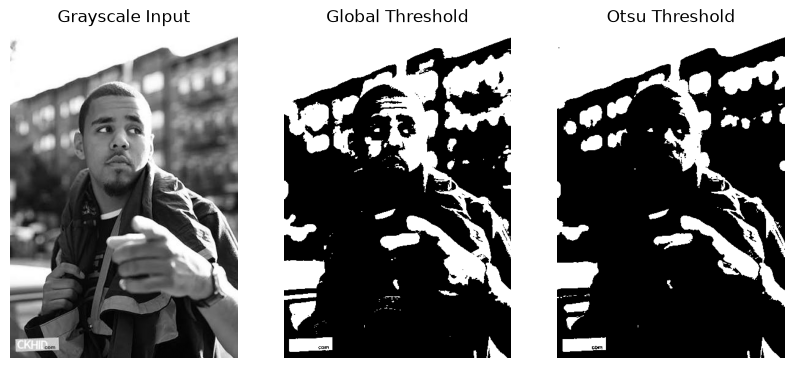

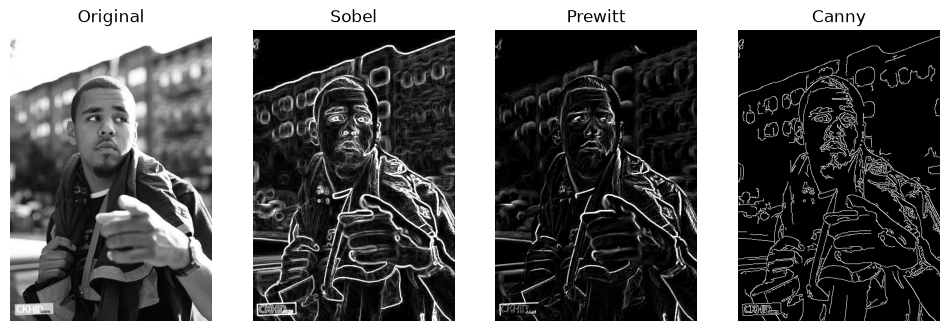

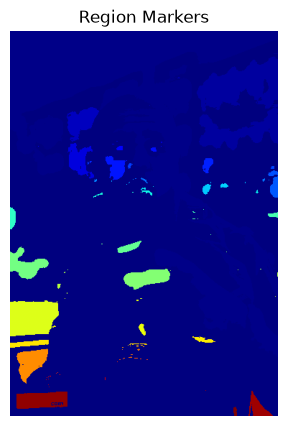

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def plot_images(original, processed, title_processed="Processed Image"):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap="gray")
    plt.title(title_processed)
    plt.axis("off")
    plt.show()


img = cv2.imread(r"C:\Users\X\Desktop\jcole.jpg", cv2.IMREAD_GRAYSCALE)
kernel = np.ones((5, 5), np.uint8)

eroded_img = cv2.erode(img, kernel, iterations=1)
plot_images(img, eroded_img, "After Erosion")

dilated_img = cv2.dilate(img, kernel, iterations=1)
plot_images(img, dilated_img, "After Dilation")

boundary = img - eroded_img
plot_images(img, boundary, "Extracted Boundary")

_, binary_img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
skel = np.zeros(binary_img.shape, np.uint8)
element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
temp_img = binary_img.copy()

while True:
    eroded = cv2.erode(temp_img, element)
    temp = cv2.dilate(eroded, element)
    temp = cv2.subtract(temp_img, temp)
    skel = cv2.bitwise_or(skel, temp)
    temp_img = eroded.copy()
    if cv2.countNonZero(temp_img) == 0:
        break

plot_images(binary_img, skel, "Thinned / Skeletonized Image")


mask = np.zeros((binary_img.shape[0] + 2, binary_img.shape[1] + 2), np.uint8)
filled_img = binary_img.copy()
cv2.floodFill(filled_img, mask, (0, 0), 255) 
filled_img = cv2.bitwise_not(filled_img)
plot_images(binary_img, filled_img, "Region Filled Image")

_, thresh_global = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
_, thresh_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1); plt.imshow(img, cmap='gray'); plt.title("Grayscale Input"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(thresh_global, cmap='gray'); plt.title("Global Threshold"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(thresh_otsu, cmap='gray'); plt.title("Otsu Threshold"); plt.axis('off')
plt.show()

sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)
sobel_abs = cv2.convertScaleAbs(sobel_combined)

prewitt_kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
prewitt_kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)
prewitt_x = cv2.filter2D(img, -1, prewitt_kernel_x)
prewitt_y = cv2.filter2D(img, -1, prewitt_kernel_y)
prewitt_combined = cv2.magnitude(prewitt_x.astype(np.float64), prewitt_y.astype(np.float64))
prewitt_abs = cv2.convertScaleAbs(prewitt_combined)

canny_edges = cv2.Canny(img, 50, 150)

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1); plt.imshow(img, cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(1, 4, 2); plt.imshow(sobel_abs, cmap='gray'); plt.title("Sobel"); plt.axis('off')
plt.subplot(1, 4, 3); plt.imshow(prewitt_abs, cmap='gray'); plt.title("Prewitt"); plt.axis('off')
plt.subplot(1, 4, 4); plt.imshow(canny_edges, cmap='gray'); plt.title("Canny"); plt.axis('off')
plt.show()

ret, markers = cv2.connectedComponents(thresh_global)
plt.figure(figsize=(5, 5))
plt.imshow(markers, cmap='jet')
plt.title("Region Markers")
plt.axis('off')
plt.show()